# Target Volume Qualitative RECIST calculation  
Determining target volume selection based on diameter and performing RECIST with sum of diameters of up to 5 lesions.

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/recist-vs-reality


In [148]:
import pandas as pd
from pathlib import Path
from damply import dirs
from workflow.scripts.utils.metadata_ll import add_source_labels, add_sample_id_column
from workflow.scripts.lesion_locator_sim import get_recist_tum , get_indiv_percdiam_change

In [149]:
def calc_RECIST(target_lesions: pd.DataFrame,
                t1_diam_col: str,
                t2_diam_col: str
                ) -> tuple[str, float]:
    
    sld_t1 = target_lesions[t1_diam_col].sum()
    sld_t2 = target_lesions[t2_diam_col].sum()

    delta_sld = sld_t2 - sld_t1

    delta_perc_diam = get_indiv_percdiam_change(sld_t1, sld_t2)

    response_cat = get_recist_tum(diam_change = delta_perc_diam)

    return response_cat, delta_sld, delta_perc_diam

In [164]:
dataset = "CVPR_LesionLocator" # Lesion Locator
model = "nnint"

In [165]:
model_results_path = Path(f"data/results/{dataset}/{model}_ll_sim_plotting_info.csv")
model_results_df = pd.read_csv(model_results_path)

In [166]:
name_mapping_df = pd.read_csv(dirs.RAWDATA / dataset / "images" / "naming.csv")

lbl_model_results_df = add_sample_id_column(model_results_df, "GT_t1_mask_path")
lbl_model_results_df = add_source_labels(lbl_model_results_df, name_mapping_df)

In [167]:
# lbl_model_results_df

# Single Patient Calculations

In [18]:
source_id = 'KiTS23_case_00002'
pat_data = lbl_model_results_df[lbl_model_results_df['source_id'] == source_id]

In [19]:
pat_data

,GT_t1_mask_path,GT_t2_mask_path,GT_t1_max_ax_diam,GT_t2_max_ax_diam,GT_t1_vox_vol,GT_t2_vox_vol,GT_perc_diam_change,GT_perc_vol_change,GT_RECIST_cat,PRED_t1_mask_path,...,t1_DICE,t2_DICE,t1_2D_DICE,t2_2D_DICE,t1_HD95,t2_HD95,RECIST_flip,sample_id,source_id,source_dataset
3,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,20.689309,23.486328,3961.866489,4129.555202,13.519152,4.232569,SD,data/results/MultiSite/CVPR_LesionLocator/pred...,...,0.849071,0.826375,0.957241,0.878412,3.757812,2.818359,False,LesionLocator_0003,KiTS23_case_00002,KiTS
4,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,46.262701,51.154926,37011.546692,52394.779686,10.574880,41.563335,SD,data/results/MultiSite/CVPR_LesionLocator/pred...,...,0.913582,0.918523,0.970476,0.964305,5.476004,6.269201,False,LesionLocator_0003,KiTS23_case_00002,KiTS
5,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,42.275391,43.863508,35874.793732,19493.371609,3.756600,-45.662763,SD,data/results/MultiSite/CVPR_LesionLocator/pred...,...,0.909511,0.869629,0.960171,0.911635,6.184799,4.227275,False,LesionLocator_0003,KiTS23_case_00002,KiTS


In [21]:
# Sort by GT_t1_max_ax_diam, select top 5 largets lesions by diameter
target_lesions = pat_data.sort_values(by="GT_t1_max_ax_diam", ascending=False).head(5)

gt_response_cat, gt_delta_sld = calc_RECIST(target_lesions, "GT_t1_max_ax_diam", "GT_t2_max_ax_diam")

pred_response_cat, pred_delta_sld = calc_RECIST(target_lesions, "PRED_t1_max_ax_diam", "PRED_t2_max_ax_diam")

print(f'Patient: {source_id}')
print(f"Number of Target Lesions: {len(target_lesions)}")
print(f"GT RECIST response category: {gt_response_cat}, GT delta SLD: {gt_delta_sld}")
print(f"PRED RECIST response category: {pred_response_cat}, PRED delta SLD: {pred_delta_sld}")

Patient: KiTS23_case_00002
Number of Target Lesions: 3
GT RECIST response category: SD, GT delta SLD: 9.277361834639223
PRED RECIST response category: SD, PRED delta SLD: 12.371297705351736


# Whole Dataset Calculations

In [168]:
response_data = {}

for idx, pat_data in lbl_model_results_df.groupby(by=["source_id"]):
    ll_id = pat_data['sample_id'].iloc[0]
    source_id = pat_data['source_id'].iloc[0]
    target_lesions = pat_data.sort_values(by="GT_t1_max_ax_diam", ascending=False).head(5)

    gt_response_cat, gt_delta_sld, gt_delta_perc_diam = calc_RECIST(target_lesions, "GT_t1_max_ax_diam", "GT_t2_max_ax_diam")

    pred_response_cat, pred_delta_sld, pred_delta_perc_diam = calc_RECIST(target_lesions, "PRED_t1_max_ax_diam", "PRED_t2_max_ax_diam")

    response_data[ll_id] = {
        "source_id": source_id,
        "num_target_lesions": len(target_lesions),
        "gt_response_cat": gt_response_cat,
        "pred_response_cat": pred_response_cat,
        "gt_delta_sld": gt_delta_sld,
        "pred_delta_sld": pred_delta_sld,
        "gt_delta_perc_diam": gt_delta_perc_diam,
        "pred_delta_perc_diam": pred_delta_perc_diam,
    }

    for column in ['t1_DICE', 't2_DICE', 't1_2D_DICE', 't2_2D_DICE', 't1_HD95', 't2_HD95']:
        response_data[ll_id][f"avg_{column}"] = target_lesions[column].mean()
        response_data[ll_id][f"targets_{column}"] = target_lesions[column].to_list()

    for column in ['GT_t1_max_ax_diam', 'GT_t2_max_ax_diam', 'PRED_t1_max_ax_diam', 'PRED_t2_max_ax_diam']:
        response_data[ll_id][f"sum_{column}"] = target_lesions[column].sum()

In [169]:
target_recist_results = pd.DataFrame().from_dict(response_data, orient='columns').T

target_recist_results["RECIST_flip"] = target_recist_results.apply(lambda row: row['gt_response_cat'] != row['pred_response_cat'], axis=1)

In [170]:
# Save out data frame
target_recist_results_path = dirs.RESULTS / dataset / f"{model}_ll_target_recist_results.csv"

target_recist_results.to_csv(target_recist_results_path)

# Plots

In [157]:
import matplotlib.pyplot as plt
import numpy as np

In [171]:
# Set up human readable model title for plotting
match model:
    case "nnint":
        model_title = "nnInteractive"
    case "ms2r":
        model_title = "MedSAM2-RECIST"
    case _:
        model_title = model

In [172]:
def response_hexbin_plots(target_recist_results: pd.DataFrame, x_val: str, y_val: str, model_title: str, count_vmax: int = 70, grid_size: int = 30) -> plt.Figure:

    hex_fig, hex_axes = plt.subplots(figsize=(23, 7), nrows = 1, ncols = 3, tight_layout=True)

    count_gridsize = grid_size
    count_cmap = 'gist_rainbow'
    count_vmin = 0

    # Left plot coloured by number of samples in each bin
    count_ax = hex_axes[0]

    count_hb = count_ax.hexbin(x=target_recist_results[x_val],
                            y=target_recist_results[y_val],
                            gridsize=count_gridsize,
                            cmap=count_cmap,
                            mincnt=1,
                            vmin=count_vmin,
                            vmax=count_vmax)
    count_ax.set_title("Count of Samples in Bin")
    count_ax.set_xlabel(x_val) 
    count_ax.set_ylabel(y_val)
    count_cb = hex_fig.colorbar(count_hb, ax = count_ax)


    # Middle plot coloured by RECIST flip
    flip_ax = hex_axes[1]
    flip_hb = flip_ax.hexbin(x=target_recist_results[x_val],
                            y=target_recist_results[y_val],
                            C=target_recist_results['RECIST_flip'],
                            reduce_C_function=np.mean,
                            gridsize=count_gridsize,
                            cmap='cool',
                            mincnt=1)
    flip_ax.set_title("RECIST Flip Rate in Bin")
    flip_ax.set_xlabel(x_val)
    flip_ax.set_ylabel(y_val)
    flip_cb = hex_fig.colorbar(flip_hb, ax = flip_ax)


    # Right plot coloured by alpha based on count, with color representing RECIST flip
    aflip_ax = hex_axes[2]
    aflip_hb = aflip_ax.hexbin(x=target_recist_results[x_val],
                            y=target_recist_results[y_val],
                            C=target_recist_results['RECIST_flip'],
                            reduce_C_function=np.mean,
                            gridsize=count_gridsize,
                            cmap='cool',
                            mincnt=1)
    aflip_ax.figure.canvas.draw() # Need to draw the canvas to create the colorbar

    # Set alpha of each hexbin based on count in that bin
    fcolors = aflip_hb.get_facecolors()
    scaled_count = np.minimum(count_hb.get_array() / count_vmax, 1)
    fcolors[:, 3] = scaled_count
    aflip_hb.set(array=None, facecolor=fcolors)

    aflip_ax.set_title("Alpha-by-count RECIST Flip Rate in Bin")
    aflip_ax.set_xlabel(x_val)
    aflip_ax.set_ylabel(y_val)
    aflip_cb = hex_fig.colorbar(aflip_hb, ax = aflip_ax)

    hex_fig.suptitle(f"{model_title} - Target Lesion RECIST Plots \n alpha max = {count_vmax}", fontsize=16)

    return hex_fig


In [173]:
# hex_fig.savefig(dirs.RESULTS / dataset / f"{model}_ll_target_recist_{x_val}_{y_val}_hexbin.png")

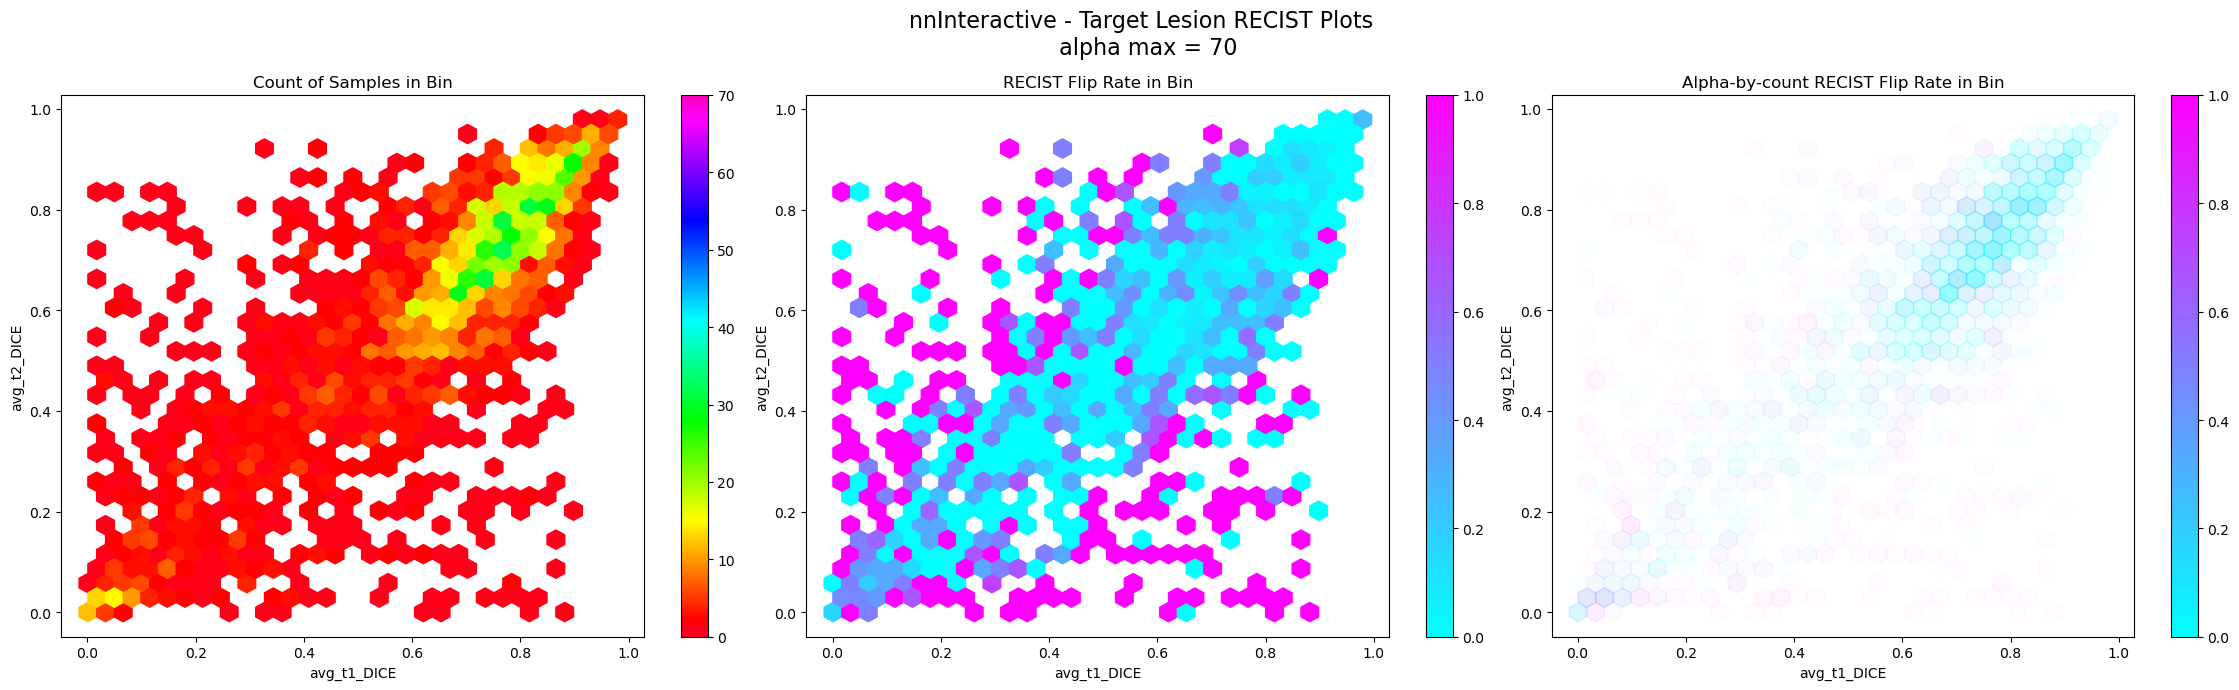

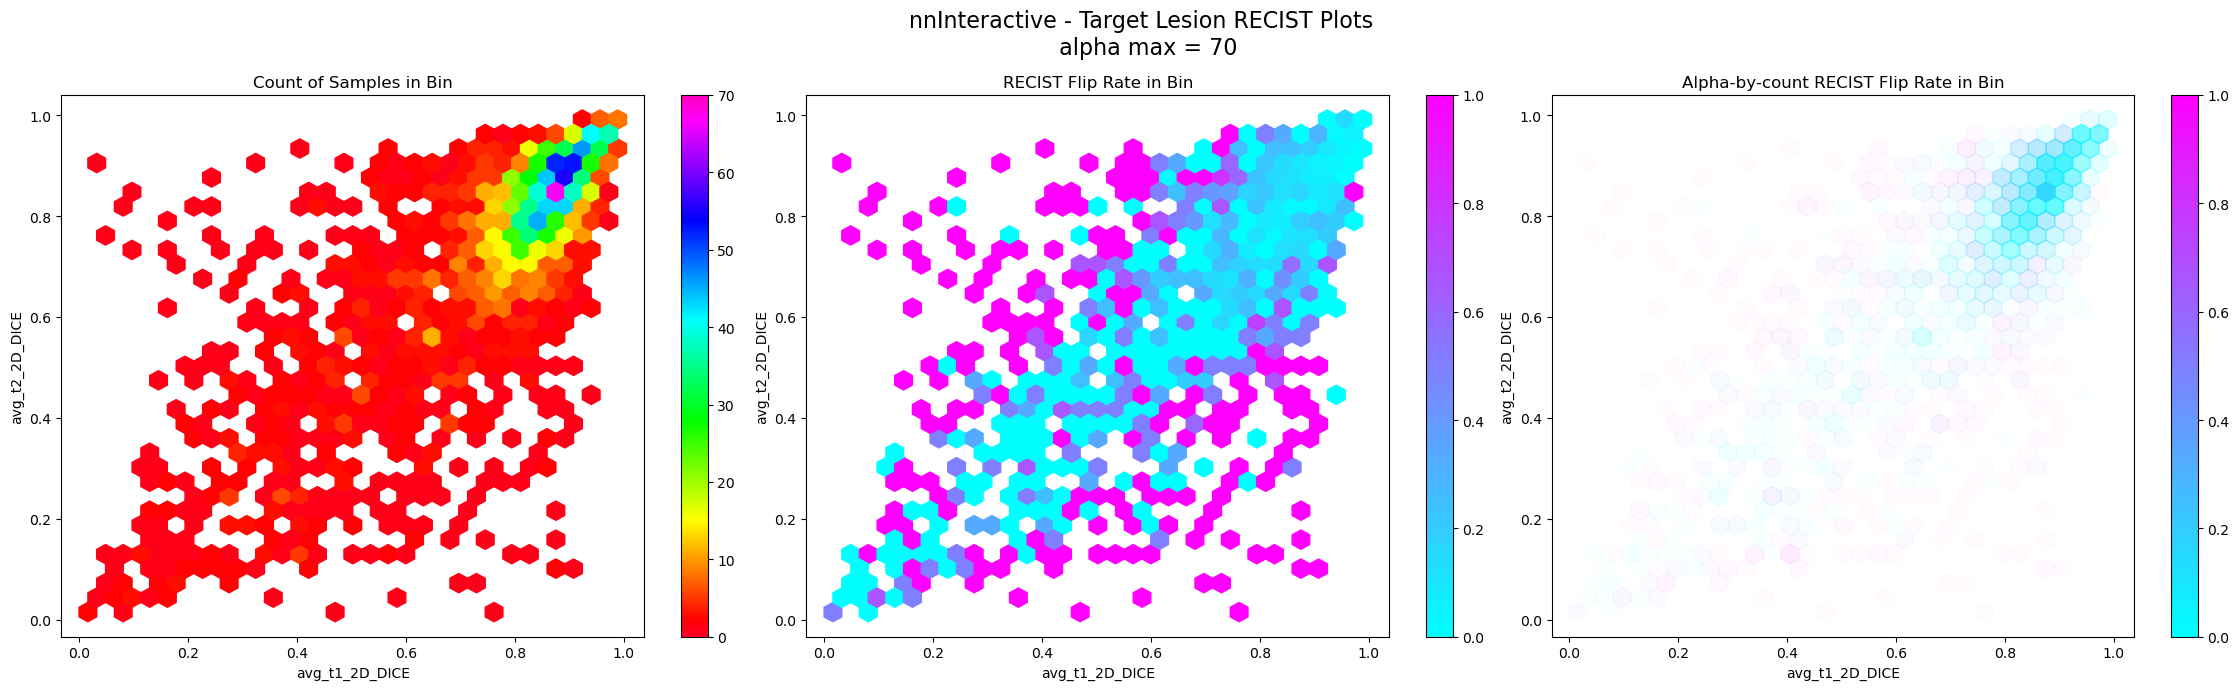

In [174]:
dice_2d = response_hexbin_plots(target_recist_results, "avg_t1_DICE", "avg_t2_DICE", model_title, count_vmax=70)
dice_3d = response_hexbin_plots(target_recist_results, "avg_t1_2D_DICE", "avg_t2_2D_DICE", model_title, count_vmax = 70)

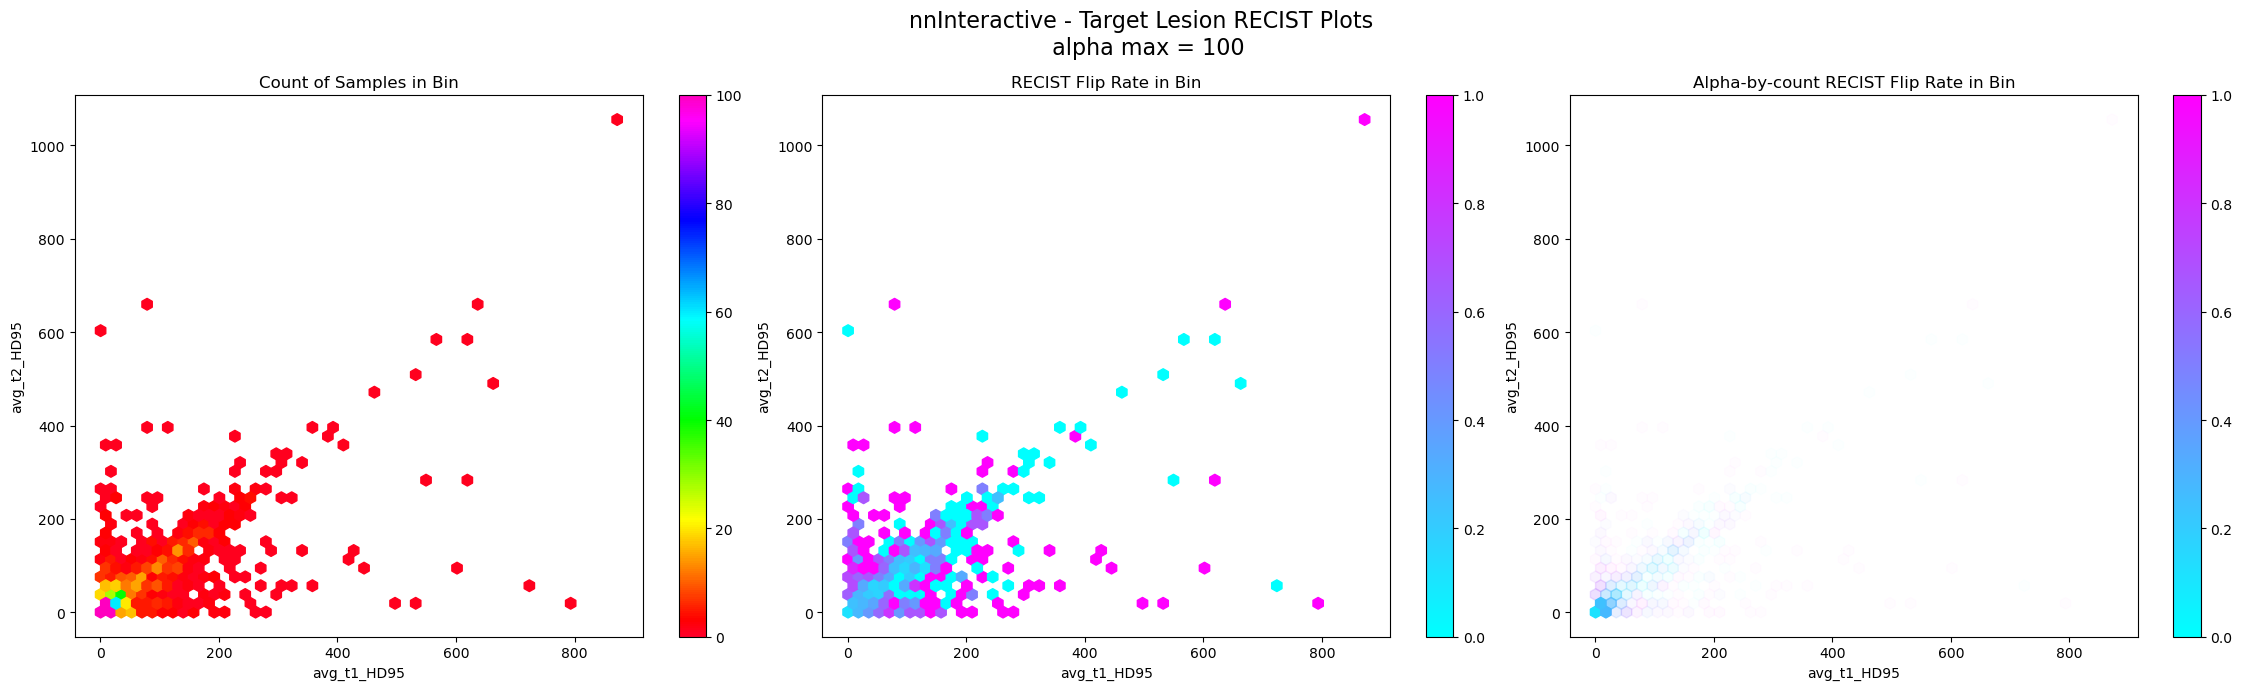

In [175]:
hd95 = response_hexbin_plots(target_recist_results, "avg_t1_HD95", "avg_t2_HD95", model_title, count_vmax=100, grid_size=50)

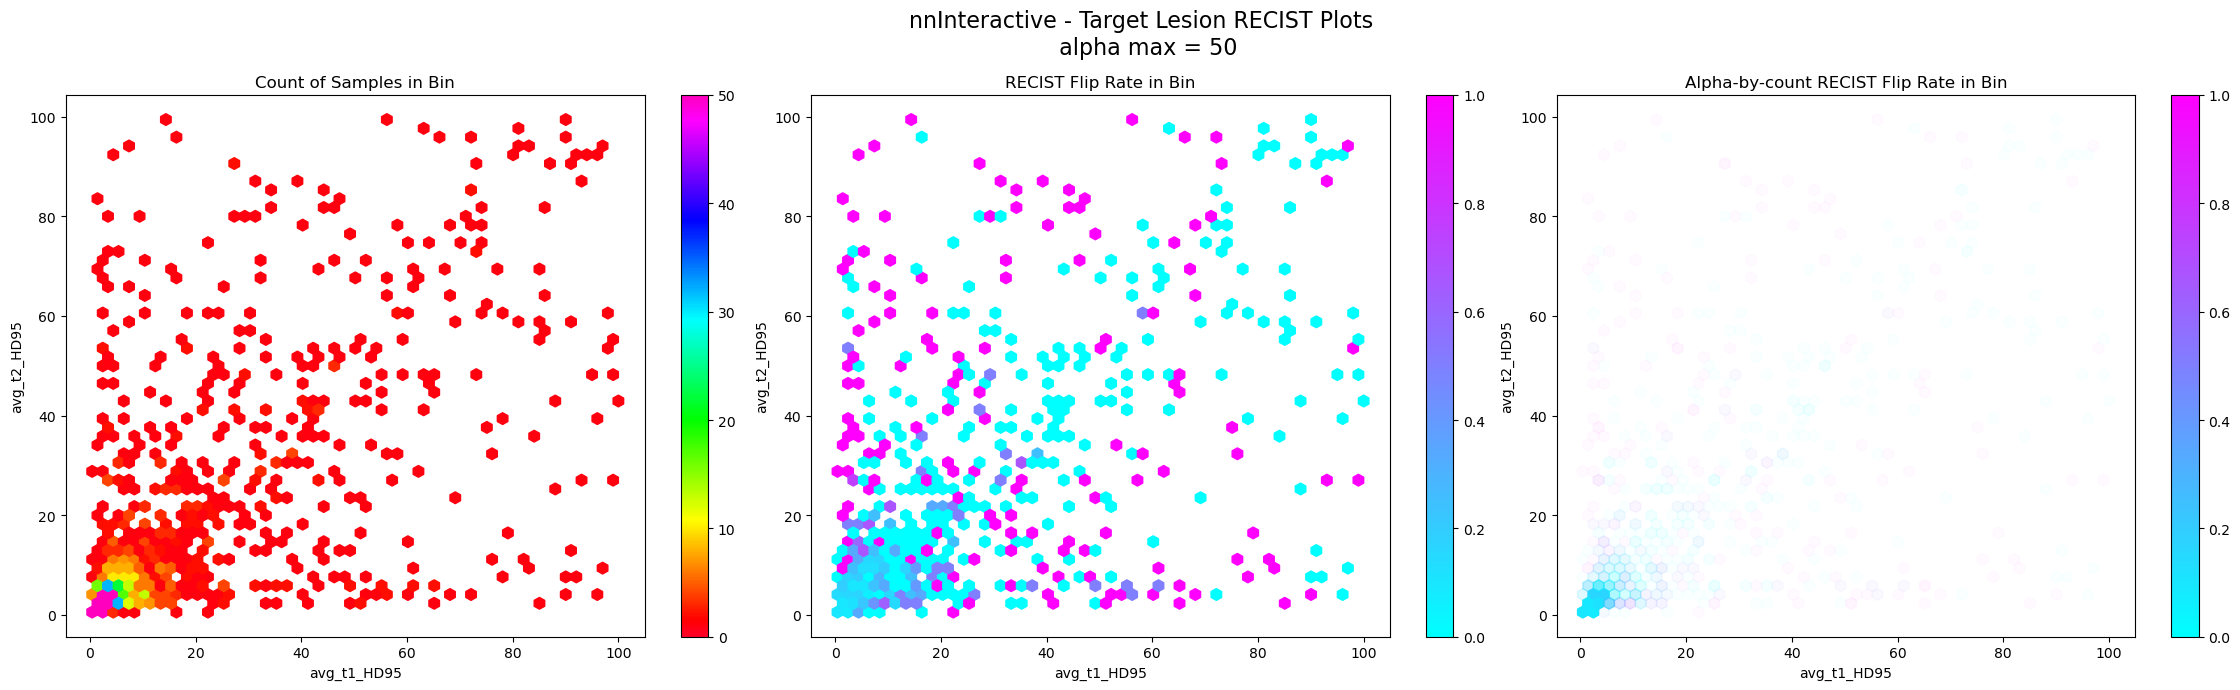

In [176]:
dropout_target_lesions = target_recist_results[(target_recist_results['avg_t1_HD95'] < 100)]
dropout_target_lesions = dropout_target_lesions[dropout_target_lesions['avg_t2_HD95'] < 100]

hd95_below_100 = response_hexbin_plots(dropout_target_lesions, "avg_t1_HD95", "avg_t2_HD95", model_title, count_vmax=50, grid_size=50)

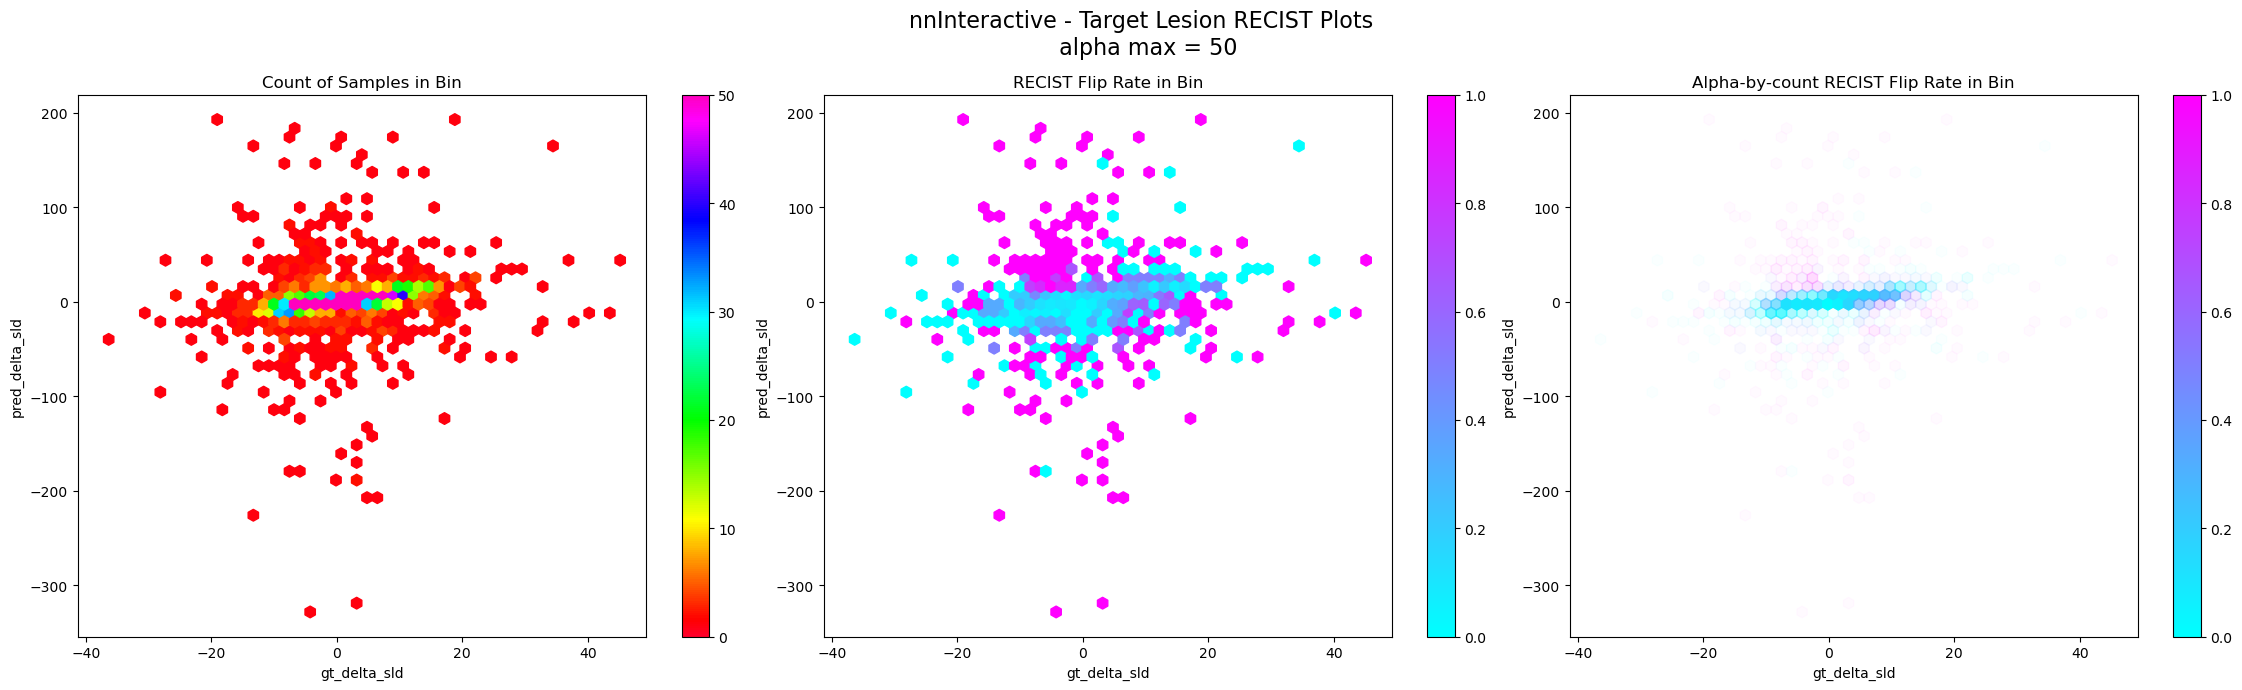

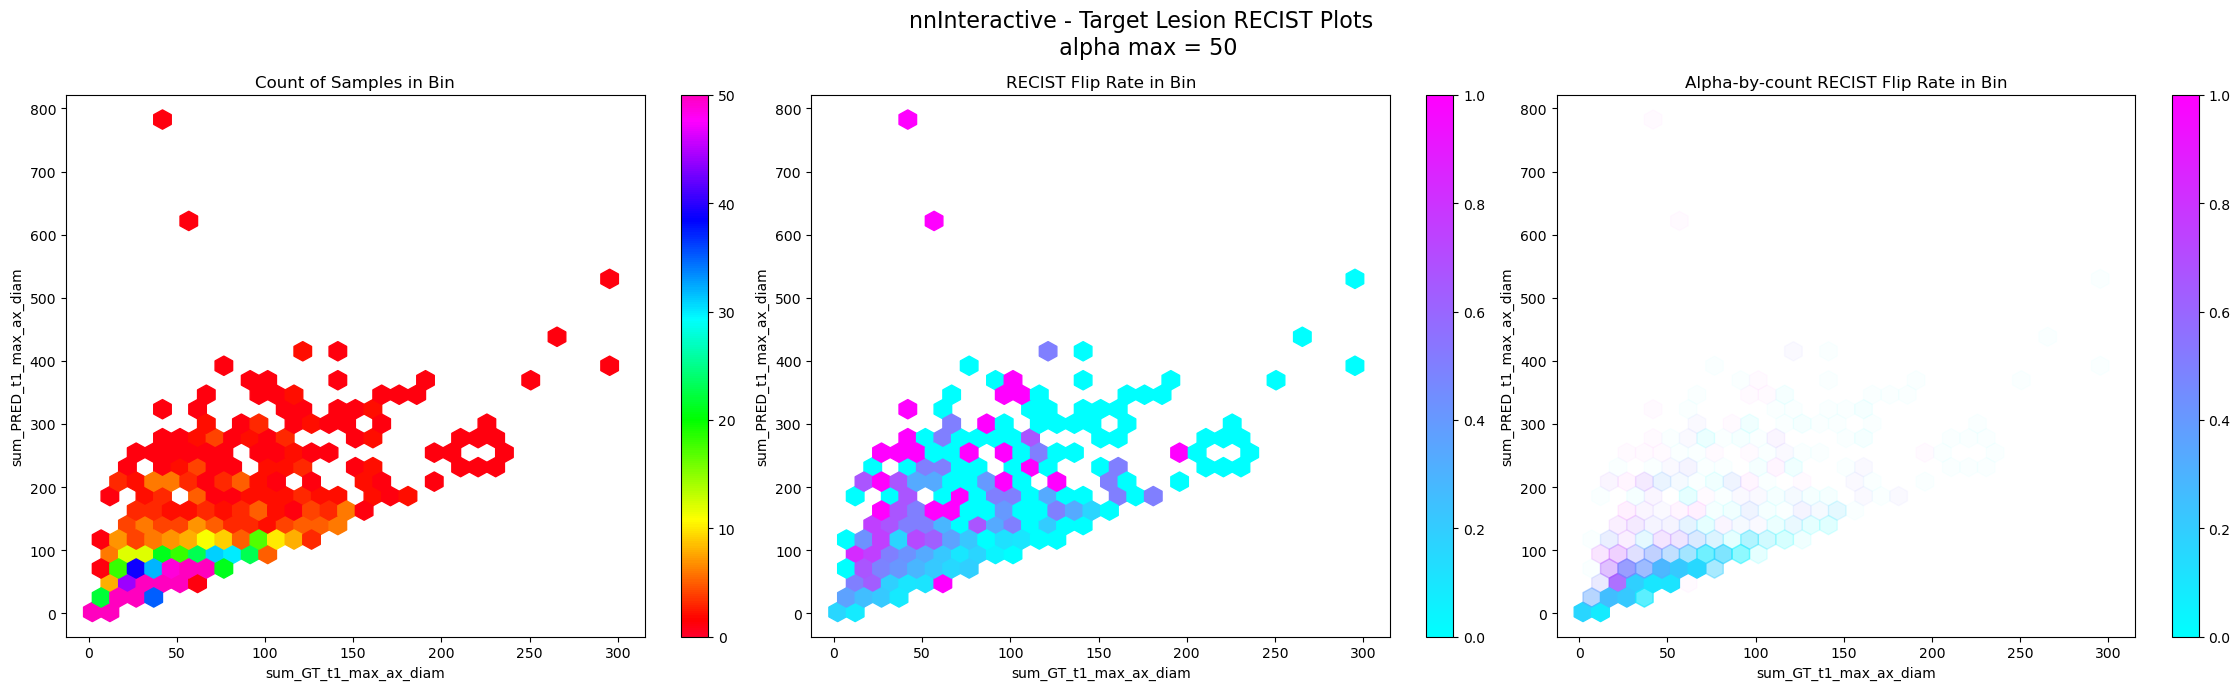

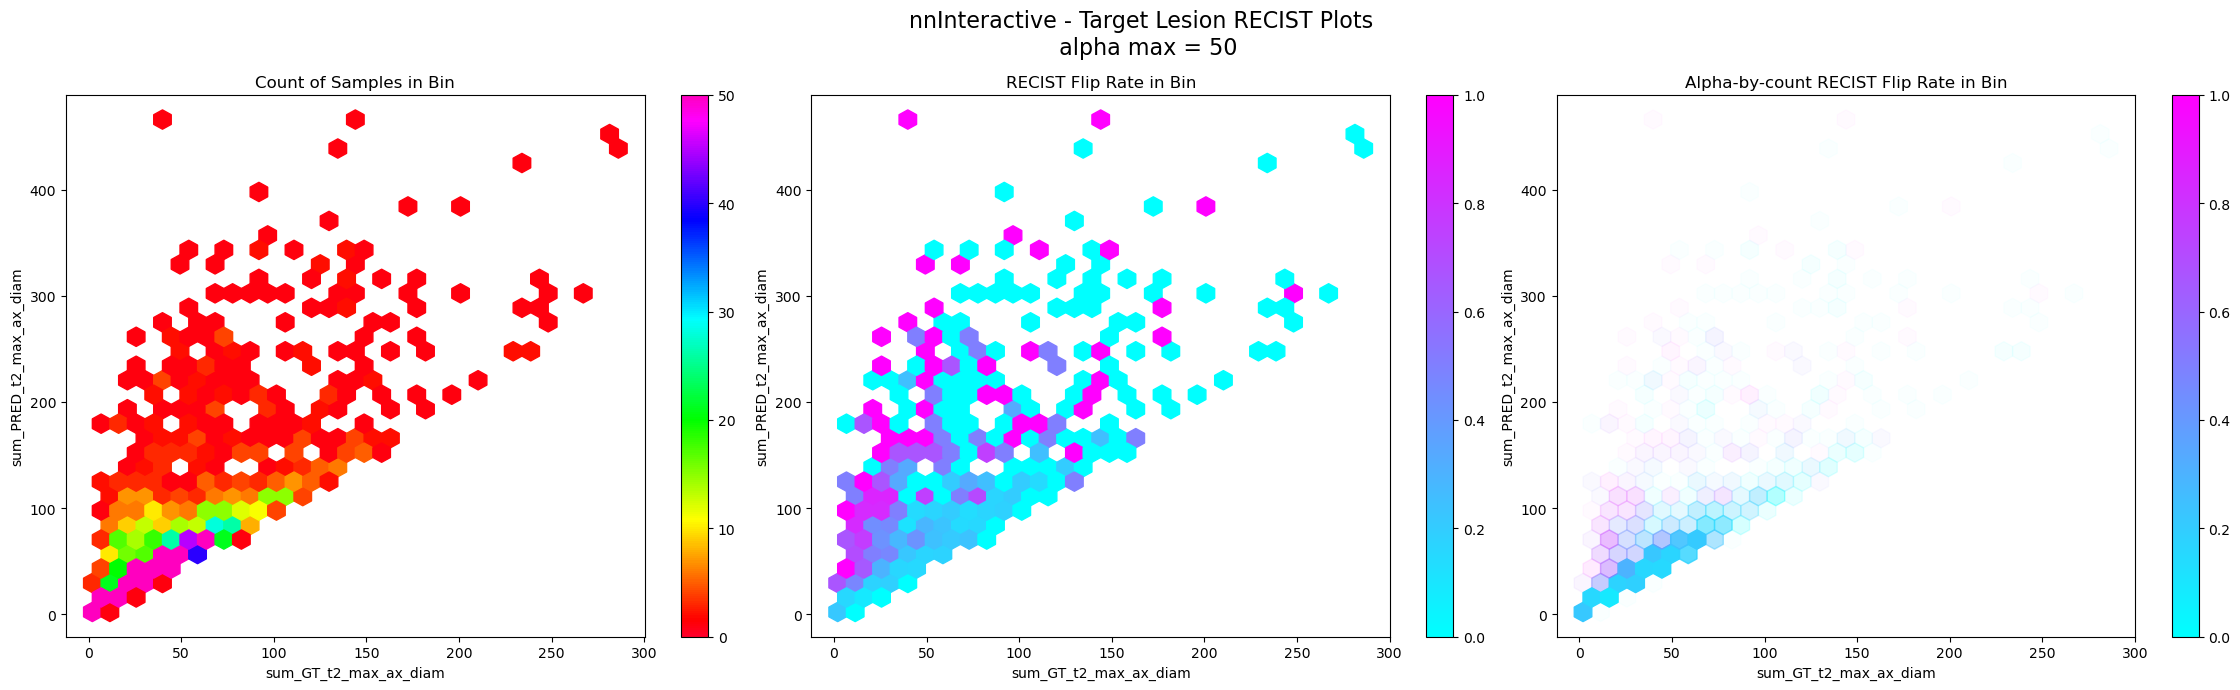

In [177]:
delta_sld = response_hexbin_plots(target_recist_results, "gt_delta_sld", "pred_delta_sld", model_title, count_vmax=50, grid_size=50)
t1_diam = response_hexbin_plots(target_recist_results, "sum_GT_t1_max_ax_diam", "sum_PRED_t1_max_ax_diam", model_title, count_vmax=50, grid_size=30)
t2_diam = response_hexbin_plots(target_recist_results, "sum_GT_t2_max_ax_diam", "sum_PRED_t2_max_ax_diam", model_title, count_vmax=50, grid_size=30)

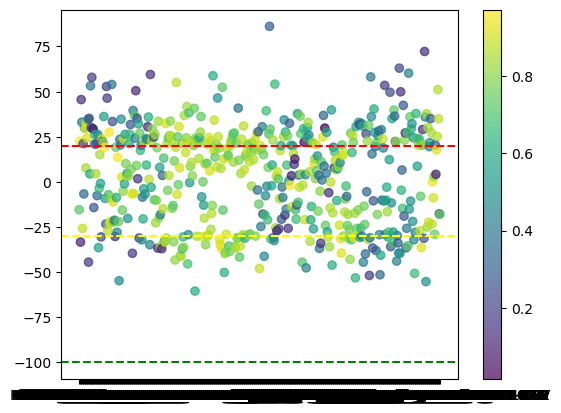

In [184]:
flipped_target_lesions = target_recist_results[target_recist_results['RECIST_flip'] == True]

plt.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_diam'], c=flipped_target_lesions['avg_t1_2D_DICE'], cmap='viridis', alpha=0.7)
plt.axhline(y = -100, linestyle='--', color='green')
plt.axhline(y = -30, linestyle='--', color='yellow')
plt.axhline(y = 20, linestyle='--', color='red')
cb = plt.colorbar()

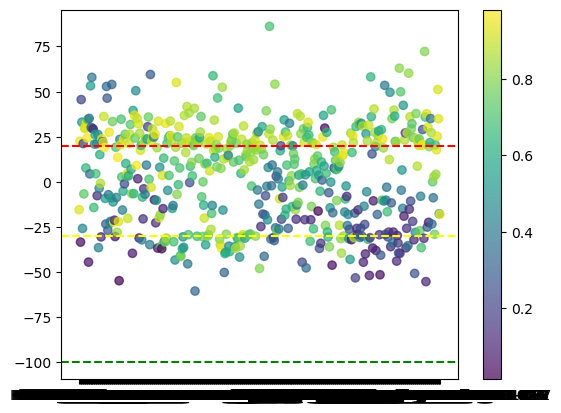

In [185]:
flipped_target_lesions = target_recist_results[target_recist_results['RECIST_flip'] == True]

plt.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_diam'], c=flipped_target_lesions['avg_t2_2D_DICE'], cmap='viridis', alpha=0.7)
plt.axhline(y = -100, linestyle='--', color='green')
plt.axhline(y = -30, linestyle='--', color='yellow')
plt.axhline(y = 20, linestyle='--', color='red')
cb = plt.colorbar()

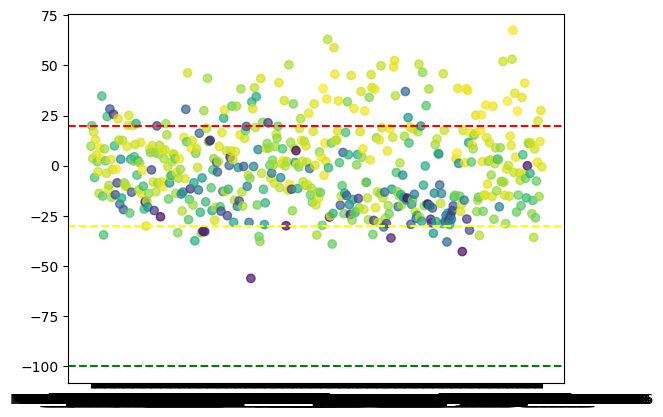

In [189]:
correct_target_lesions = target_recist_results[target_recist_results['RECIST_flip'] == False]

correct_target_lesions = correct_target_lesions[-500:]

plt.scatter(correct_target_lesions['source_id'], correct_target_lesions['gt_delta_perc_diam'], c=correct_target_lesions['avg_t2_2D_DICE'], cmap='viridis', alpha=0.7)
plt.axhline(y = -100, linestyle='--', color='green')
plt.axhline(y = -30, linestyle='--', color='yellow')
plt.axhline(y = 20, linestyle='--', color='red')